In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# We are not use any external data set for this example we create our own data set
from collections import Counter
from sklearn.datasets import make_classification

# When we have imbalanced data we use class_weights parameter to balance the data
# create dataset since we are solving multiclass  classification problem so we keep number of class is 3    

In [3]:
# create dataset since we are solving binary multiclass  classification problem so we keep number of class is 2
X,y = make_classification(n_samples=10000, n_features=10, n_classes=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42, weights=[0.99])

In [4]:
X

array([[-0.14672028,  0.86733983, -0.08116425, ..., -1.39552143,
        -0.2160667 ,  2.97590704],
       [ 0.17529358, -1.22257737, -0.87363869, ..., -0.01610929,
        -1.21311147, -0.96776234],
       [-0.66640166,  0.29708364, -1.48327096, ...,  0.48077542,
        -0.32719384,  0.37721239],
       ...,
       [ 0.78657064, -1.58265967, -0.73757642, ..., -1.14502224,
         0.31727494,  1.24190753],
       [-1.25887002, -0.45837934, -1.95232893, ..., -0.1385498 ,
         1.14854282, -2.25213679],
       [ 0.682537  ,  1.15809581,  1.19117349, ..., -0.46647401,
         0.77035266,  2.47426446]], shape=(10000, 10))

In [5]:
y

array([0, 0, 0, ..., 0, 0, 0], shape=(10000,))

In [6]:


Counter(y)

Counter({np.int64(0): 9863, np.int64(1): 137})

In [7]:
import seaborn as sns

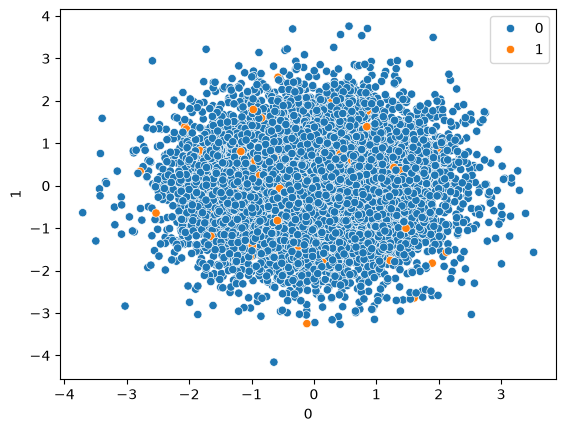

In [8]:
import pandas as pd 

X_df = pd.DataFrame(X)

sns.scatterplot(
    x=X_df[0],
    y=X_df[1],
    hue=y
)

plt.show()




In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [10]:
class_weights = [
    {0: w, 1: y}
    for w in [1, 10, 50, 100]
    for y in [1, 10, 50, 100]
]

In [11]:
# set the class weights
class_weights

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [12]:
## Hyperparameter tuning
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
penalty = ['l1', 'l2', 'elasticnet']
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
solver = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
class_weights = [
    {0: w, 1: y}
    for w in [1, 10, 50, 100]
    for y in [1, 10, 50, 100]
]


In [13]:
# make all parmse into key value pair
params = dict(penalty=penalty, C=C_values, solver=solver, class_weight=class_weights)




In [14]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Grid Search Hyperparameter Optimization
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(estimator=model, param_grid=params, scoring='accuracy', cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)
  

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged::